In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Pushing water the other way (Problem 11.5-13)

Every other appearance of osmosis in this chapter is something that happens **to**
you: the pressure that bursts a red blood cell, the pressure that lifts a column of
water fifteen meters up Joe Udel's pipe, the pressure that decides whether a
membrane demonstration is possible at all. Reverse osmosis is the one case where you
spend work to defeat it, and it is where most of the world's desalinated drinking
water comes from.

**The equation is Illustration 11.5-4's, unchanged.** Seawater is about 3.5 wt %
dissolved salts against the 0.9 wt % of blood, so the whole calculation is the one
the illustration already did, at four times the concentration. What is new is what
happens when you actually *take water out*:

1. the osmotic pressure of the feed, which sets the smallest pressure that produces
   any fresh water at all;
2. the osmotic pressure of the **brine**, which is not the same number, because the
   brine concentrates as it flows and $\Pi$ is a state function of whatever is in
   front of the membrane at that point;
3. the **work**, which is the integral of the second one over the recovery.

**The third number is the interesting one, and it is interesting in the direction
students do not expect.** The thermodynamic minimum is about 1 kWh per cubic meter
and a real seawater plant spends three to four. Desalination is not expensive
because thermodynamics forbids it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.insert(0, "..")
import numpy as np
import matplotlib.pyplot as plt

from thermo.electrolytes import DebyeHuckel
from thermo.osmotic import osmotic_pressure, electrolyte_mole_fraction

T = 298.15
V_WATER = 18e-6          # m^3/mol, the value Illustration 11.5-4 uses
MW_NACL = 58.44

# The SAME model instance Illustration 11.5-4 uses: Eq. 9.10-18, with the beta*a and
# delta terms. A bare DebyeHuckel("NaCl") is the LIMITING LAW -- no beta*a, no
# delta -- and at seawater concentration it is not a small difference: it returns
# 21.3 bar where this returns 28.2. Name the parameters.
model = DebyeHuckel("NaCl", T=T, beta_a=1.0, delta=0.137)


def seawater_state(wt_percent):
    """Molality, water mole fraction, gamma_W and Pi (bar) for a wt % NaCl solution."""
    salt, water = wt_percent, 100.0 - wt_percent
    M = (salt / MW_NACL) / (water / 1000.0)
    x_W = electrolyte_mole_fraction(M, nu=2)
    gamma_W = float(model.solvent_gamma(M))
    Pi = osmotic_pressure(x_W, V_WATER, T, gamma_solvent=gamma_W) / 1e5
    return M, x_W, gamma_W, Pi


print("  (a) the osmotic pressure of seawater, 3.5 wt % as NaCl")
M, x_W, gamma_W, Pi_feed = seawater_state(3.5)
print(f"    molality      = {M:.4f} mol/kg")
print(f"    x_W           = {x_W:.6f}")
print(f"    gamma_W       = {gamma_W:.6f}")
print(f"    Pi            = {Pi_feed:.2f} bar")

M_b, x_b, g_b, Pi_blood = seawater_state(0.9)
Pi_ideal = osmotic_pressure(x_W, V_WATER, T) / 1e5
print(f"\n    against blood (0.9 wt %, Illustration 11.5-4): {Pi_blood:.2f} bar")
print(f"    ratio of pressures {Pi_feed/Pi_blood:.2f} for a salt ratio of {3.5/0.9:.2f}")
print(f"    ideal solution, gamma_W = 1:                   {Pi_ideal:.2f} bar"
      f"   ({100*(Pi_ideal/Pi_feed - 1):.0f} % high)")
print(f"\n  (b) the smallest applied pressure that produces any fresh water:"
      f" {Pi_feed:.2f} bar")

  (a) the osmotic pressure of seawater, 3.5 wt % as NaCl
    molality      = 0.6206 mol/kg
    x_W           = 0.978128
    gamma_W       = 1.001636
    Pi            = 28.21 bar

    against blood (0.9 wt %, Illustration 11.5-4): 7.07 bar
    ratio of pressures 3.99 for a salt ratio of 3.89
    ideal solution, gamma_W = 1:                   30.46 bar   (8 % high)

  (b) the smallest applied pressure that produces any fresh water: 28.21 bar


## Part (c): the pressure is not one number, it is a profile

This is the part a flowsheet cannot fake. The membrane passes water and rejects salt,
so as the feed travels along the module the salt it started with is left behind in a
shrinking amount of water. The osmotic pressure is a property of **the brine in front
of the membrane at that point**, not of the feed, so it rises monotonically from the
inlet to the outlet.

Nothing in the calculation below is a membrane property. Recovery and pressure are
coupled by a mass balance and Eq. 11.5-4, and by nothing else -- which is why this is
a thermodynamics problem and not a separations problem.

Basis: 1000 g of feed, which is 35 g of salt and 965 g of water. At a recovery $r$
(mass of fresh water produced per mass of feed) the brine holds all 35 g of the salt
in $965 - 1000r$ grams of water.

In [3]:

SALT_G, WATER_G = 35.0, 965.0        # per 1000 g of feed


def brine(recovery):
    """wt %, molality and Pi (bar) of the brine at fractional recovery."""
    water = WATER_G - 1000.0 * recovery
    wt = 100.0 * SALT_G / (SALT_G + water)
    M, _, _, Pi = seawater_state(wt)
    return wt, M, Pi


print(f"  {'recovery':>9s} {'brine wt %':>11s} {'molality':>9s} {'Pi (bar)':>9s}")
for r in (0.0, 0.10, 0.20, 0.30, 0.40, 0.50):
    wt, M_r, Pi_r = brine(r)
    mark = "   <- the plant of part (c)" if abs(r - 0.40) < 1e-9 else ""
    print(f"  {r:9.0%} {wt:11.3f} {M_r:9.4f} {Pi_r:9.2f}{mark}")

wt40, M40, Pi_out = brine(0.40)
print(f"\n  (c) at 40 % recovery the brine is {wt40:.2f} wt % and needs {Pi_out:.1f} bar,")
print(f"      which is {100*(Pi_out/Pi_feed - 1):.0f} % above the {Pi_feed:.1f} bar of part (b).")
print(f"      A plant held at {Pi_feed:.1f} bar produces essentially nothing: the brine")
print(f"      passes that pressure as soon as any water at all has been removed.")

   recovery  brine wt %  molality  Pi (bar)
         0%       3.500    0.6206     28.21
        10%       3.889    0.6924     31.57
        20%       4.375    0.7829     35.85
        30%       5.000    0.9006     41.51
        40%       5.833    1.0600     49.31   <- the plant of part (c)
        50%       7.000    1.2880     60.77

  (c) at 40 % recovery the brine is 5.83 wt % and needs 49.3 bar,
      which is 75 % above the 28.2 bar of part (b).
      A plant held at 28.2 bar produces essentially nothing: the brine
      passes that pressure as soon as any water at all has been removed.


## Part (d): the work, and why a real plant spends three times it

The reversible separation is the one in which the applied pressure always just exceeds
the local osmotic pressure, so the work per unit volume of product is the **average**
of $\Pi$ over the recovery:

$$\frac{W_{\min}}{V_{\rm product}} = \frac{1}{r}\int_0^{r}\Pi(r')\,{\rm d}r'$$

A real module is not run that way. It is held at a single pressure that must exceed
the osmotic pressure at the *outlet*, which is the largest value on the curve -- so
the constant-pressure minimum is $\Pi_{\rm out}$, and the difference between the two
is the thermodynamic cost of using one pressure for the whole module.

  route                                        bar   kWh/m^3
  feed osmotic pressure only (r -> 0)        28.21     0.783
  reversible, pressure tracks the brine      36.79     1.022
  one pressure for the whole module          49.31     1.370

  (d) the minimum work is 1.02 kWh per cubic meter of fresh water.
      A modern seawater plant uses 3 to 4, so it spends about 3.4 times
      the thermodynamic minimum. None of that gap is osmotic pressure:
      it is finite-rate transport through a real membrane, and pumps.


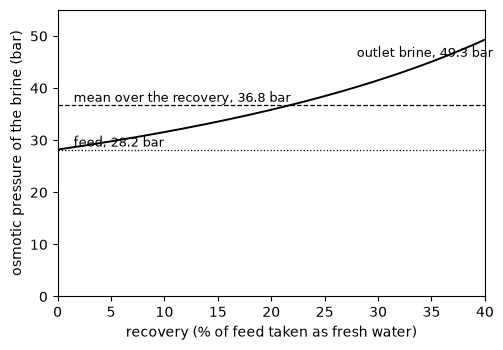

In [4]:

BAR_TO_KWH_PER_M3 = 1e5 / 3.6e6      # 1 bar of pressure-volume work per m^3

r_grid = np.linspace(1e-6, 0.40, 4001)
Pi_grid = np.array([brine(r)[2] for r in r_grid])
Pi_mean = np.trapezoid(Pi_grid, r_grid) / 0.40

routes = [
    ("feed osmotic pressure only (r -> 0)", Pi_feed),
    ("reversible, pressure tracks the brine", Pi_mean),
    ("one pressure for the whole module", Pi_out),
]
print(f"  {'route':40s} {'bar':>7s} {'kWh/m^3':>9s}")
for name, bar in routes:
    print(f"  {name:40s} {bar:7.2f} {bar*BAR_TO_KWH_PER_M3:9.3f}")

w_min = Pi_mean * BAR_TO_KWH_PER_M3
print(f"\n  (d) the minimum work is {w_min:.2f} kWh per cubic meter of fresh water.")
print(f"      A modern seawater plant uses 3 to 4, so it spends about"
      f" {3.5/w_min:.1f} times")
print(f"      the thermodynamic minimum. None of that gap is osmotic pressure:")
print(f"      it is finite-rate transport through a real membrane, and pumps.")

fig, ax = plt.subplots(figsize=(5.2, 3.6))
ax.plot(100 * r_grid, Pi_grid, color="black", lw=1.4)
ax.axhline(Pi_feed, color="black", lw=0.9, ls=":")
ax.axhline(Pi_mean, color="black", lw=0.9, ls="--")
ax.annotate(f"feed, {Pi_feed:.1f} bar", (1.5, Pi_feed), va="bottom", fontsize=9)
ax.annotate(f"mean over the recovery, {Pi_mean:.1f} bar", (1.5, Pi_mean),
            va="bottom", fontsize=9)
ax.annotate(f"outlet brine, {Pi_out:.1f} bar", (28, Pi_out - 1.2), va="top", fontsize=9)
ax.set_xlabel("recovery (% of feed taken as fresh water)")
ax.set_ylabel("osmotic pressure of the brine (bar)")
ax.set_xlim(0, 40); ax.set_ylim(0, 55)
fig.tight_layout()
plt.show()

## What the three numbers show together

**28 bar, 49 bar, 1 kWh/m³.** The first is a property of seawater and would be the
whole answer if you took an infinitesimal amount of water out of an infinite ocean.
The second is what a plant that recovers 40 % actually has to push against at its
outlet, and it is the reason real seawater modules are rated at 55 to 70 bar rather
than at 28. The third is what thermodynamics says the separation costs, and it is
small: about a third of what a household spends on electricity for the same cubic
meter of water delivered.

**The activity coefficient correction changes the answer more here than in
Illustration 11.5-4.** At 0.9 wt % the water's activity coefficient is 1.0005 and the
correction moves the answer by 8 %. At 3.5 wt % it is 1.0016, and at the 5.8 wt % of
the outlet brine it is larger still. An ideal-solution calculation is high at every
point of the curve above, and it is high by more as the brine concentrates -- so the
error does not cancel between the feed and the brine, it accumulates.

## Your turn

1. Push the recovery to 60 % and to 75 %. The pressure requirement runs away, and at
   some recovery it exceeds the burst rating of any membrane you can buy. What sets
   that limit thermodynamically, and what would the brine's salt content be there?
2. Real seawater is not sodium chloride. Recompute part (a) treating the 3.5 wt % as
   magnesium chloride instead. How much of the change is the molecular weight and how
   much is $\nu = 3$?
3. Redo the whole problem with $\gamma_W = 1$. Which of the four answers moves most in
   percentage terms, and why is it the one furthest along the module?
4. Brackish groundwater is about 0.3 wt % salt. Compute the minimum work for it at the
   same 40 % recovery. Why is inland desalination cheap enough to be routine when
   seawater desalination is not?
5. The reversible work above assumes the pressure is adjusted continuously. Compute
   the work for a two-stage plant -- 20 % recovery at one pressure, then a second
   stage taking the brine to 40 % at a higher one -- and compare it with both bounds.